## Project Title

DeepFER: Facial Emotion Recognition Using Deep Learning

## Contribution - Individual
## Team Member 1- Pawan Thakare

## Problem Statements
Facial expressions are one of the most natural ways humans communicate emotions, yet machines still struggle to accurately interpret them. Traditional methods for emotion recognition rely on manual observation or survey-based feedback, which are often subjective, time-consuming, and not scalable.

In real-world applications such as customer experience analysis, mental health monitoring, and human-computer interaction, there is a growing need for an automated, real-time system that can accurately detect human emotions from facial expressions.

The challenge lies in:

Variability in lighting conditions and facial orientations Subtle differences between emotions (e.g., fear vs surprise) Diversity in human faces and expressions Need for high accuracy and real-time processing

👉 Therefore, the problem is to design and develop a robust deep learning-based system that can automatically recognize and classify facial emotions from images with high accuracy and efficiency.

## Project Overview
DeepFER: Facial Emotion Recognition Using Deep Learning is a computer vision-based project that leverages Convolutional Neural Networks (CNNs) and Transfer Learning to classify human emotions from facial images.

he system is trained on a labeled dataset containing seven emotions:
Angry,
Disgust,
Fear,
Happy,
Neutral,
Sad,
Surprise.

The project uses:
Image preprocessing and augmentation techniques
Deep learning architectures (CNN, MobileNetV2 / VGG16)
Real-time prediction capability using a webcam

👉 The goal is to build a system that can analyze facial expressions and predict emotions accurately in real-time scenarios.

## Project Summary (Technical Highlights)
The DeepFER project successfully demonstrates the application of deep learning in solving a real-world problem of emotion recognition.

Key highlights:

Built a CNN-based model for facial emotion classification Applied transfer learning to improve accuracy Used data augmentation to enhance model robustness Evaluated model using multiple performance metrics Implemented real-time emotion detection using webcam

👉 The system is capable of identifying emotions such as happy, sad, angry, fear, surprise, neutral, and disgust with good accuracy.

## Git Hub Link
https://github.com/Pawanthakare96/DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning.git

## **Installing Required Libraries**

In [5]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [9]:
import tensorflow as tf

In [11]:
tf.__version__

'2.21.0'

In [15]:
from tensorflow import keras

keras.__version__

'3.13.2'

In [23]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Use ONLY tensorflow.keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, InceptionResNetV2
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax
!pip install opencv-python

import cv2

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 5.6 MB/s eta 0:00:08
   - -------------------------------------- 1.8/40.2 MB 5.0 MB/s eta 0:00:08
   --- ------------------------------------ 3.4/40.2 MB 6.1 MB/s eta 0:00:07
   ----- ---------------------------------- 5.2/40.2 MB 6.9 MB/s eta 0:00:06
   ------- -------------------------------- 7.1/40.2 MB 7.4 MB/s eta 0:00:05
   ------- -------------------------------- 7.6/40.2 MB 6.5 MB/s eta 0:00:05
   -------- ------------------------------- 8.1/40.2 MB 5.9 MB/s eta 0:00:06
   -------- ------------------------------- 8.1/40.2 MB 5.9 MB/s eta 0:00:06
   -------- ------------------------------- 8.1/40.2 MB 5.9 MB/s eta 0:00:06
   -------- ------------------------------- 8.1/40.2 MB 5.9 MB/s eta 0:00:06
   -------- ------------------------------- 8.4/40.2 MB 4.0 MB/s eta 0:00:09
   -------- -

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.4 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.4 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


## Data Ingestion

In [48]:
train_dir = "C:/Users/amrut/Face Emotion Recognition Dataset/images/images/train"
val_dir   = "C:/Users/amrut/Face Emotion Recognition Dataset/images/images/validation"

## **2. Data Preprocessing & Augmentation**

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

## 3. Load Data

In [51]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical'
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


## 4. Build CNN Model (Baseline)

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)))
model.add(MaxPool2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(7, activation='softmax'))  # 7 emotions

C:\Users\amrut\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 5. Compile Model

In [56]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 6. Train Model

In [60]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 1928s 2s/step - accuracy: 0.2562 - loss: 1.7941 - val_accuracy: 0.3245 - val_loss: 1.6931
Epoch 2/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 84s 94ms/step - accuracy: 0.3282 - loss: 1.6894 - val_accuracy: 0.4062 - val_loss: 1.5586
Epoch 3/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 64s 71ms/step - accuracy: 0.3788 - loss: 1.5950 - val_accuracy: 0.4418 - val_loss: 1.4315
Epoch 4/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 64s 71ms/step - accuracy: 0.4164 - loss: 1.5120 - val_accuracy: 0.4795 - val_loss: 1.3721
Epoch 5/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 64s 71ms/step - accuracy: 0.4368 - loss: 1.4573 - val_accuracy: 0.4956 - val_loss: 1.3320
Epoch 6/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 63s 70ms/step - accuracy: 0.4495 - loss: 1.4352 - val_accuracy: 0.5112 - val_loss: 1.2919
Epoch 7/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 63s 70ms/step - accuracy: 0.4643 - loss: 1.4018 - val_accuracy: 0.5187 - val_loss: 1.2605
Epoch 8/20
901/901 ━━━━━━━━━━━━━━━━━━━━ 63s 70ms/step - accuracy: 0.4726 - loss: 1.3799 - 

## 7. (Advanced) Use Transfer Learning (VGG16)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(48,48,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(7, activation='softmax')(x)

from tensorflow.keras.models import Model
model = Model(inputs=base_model.input, outputs=output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


## Predictions

In [ ]:
import numpy as np

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

221/221 ━━━━━━━━━━━━━━━━━━━━ 46s 205ms/step


## Confusion Matrix

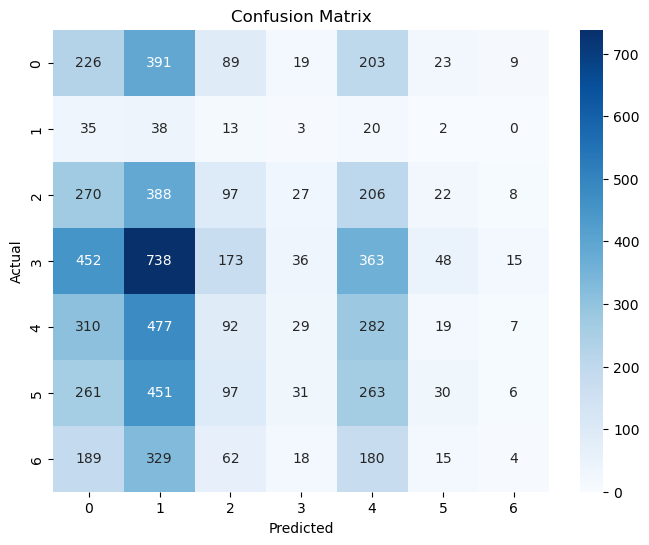

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classicifcation Reports

In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=val_generator.class_indices.keys()))

              precision    recall  f1-score   support

       angry       0.13      0.24      0.17       960
     disgust       0.01      0.34      0.03       111
        fear       0.16      0.10      0.12      1018
       happy       0.22      0.02      0.04      1825
     neutral       0.19      0.23      0.21      1216
         sad       0.19      0.03      0.05      1139
    surprise       0.08      0.01      0.01       797

    accuracy                           0.10      7066
   macro avg       0.14      0.14      0.09      7066
weighted avg       0.17      0.10      0.09      7066



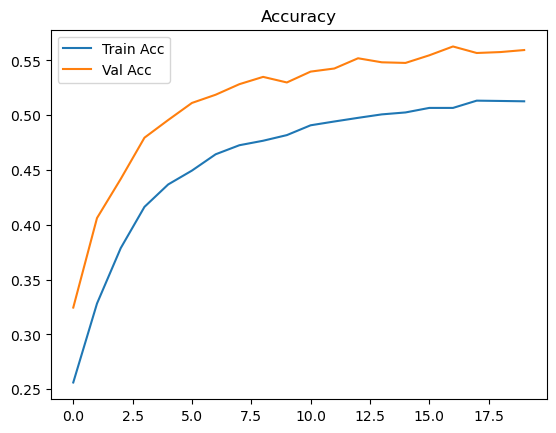

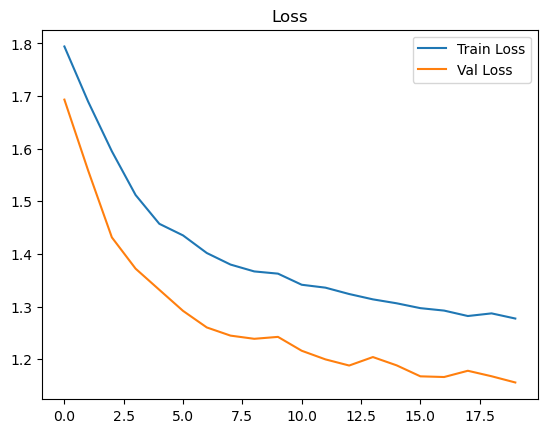

In [81]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()